# Lab 2 — EDA, Feature Engineering & Linear Regression
**Machine Learning for the Natural Sciences**

This week we move from classification to **regression** — predicting a
continuous number instead of a category. We'll predict penguin body mass
from other measurements, and learn how to **engineer features** that make
models more powerful.

**What you'll learn:**
- Deeper EDA: correlation matrices, distribution plots
- Feature engineering: creating new features from domain knowledge
- Multiple Linear Regression (MLR) with scikit-learn
- Evaluating regression: R², RMSE, residual plots
- Handling missing data with imputation (upgrade from dropna!)

---

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42

## 1. Load & Clean

In [2]:
df = sns.load_dataset("penguins")

# This time, instead of dropna, let's use imputation for numeric columns
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
imputer = SimpleImputer(strategy="median")
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# Drop remaining NaN (in categorical columns like sex)
df = df.dropna()
print(f"Rows after imputation + cleanup: {len(df)}")

Rows after imputation + cleanup: 333


### 🔍 Your Turn
**TODO:** Why did we use median imputation instead of mean? When might
mean be a bad choice? (Hint: think about outliers in body_mass_g.)

*Your answer:*

## 2. Deeper EDA
Last week we used pairplots. This week we add **correlation matrices**
and **distribution analysis**.

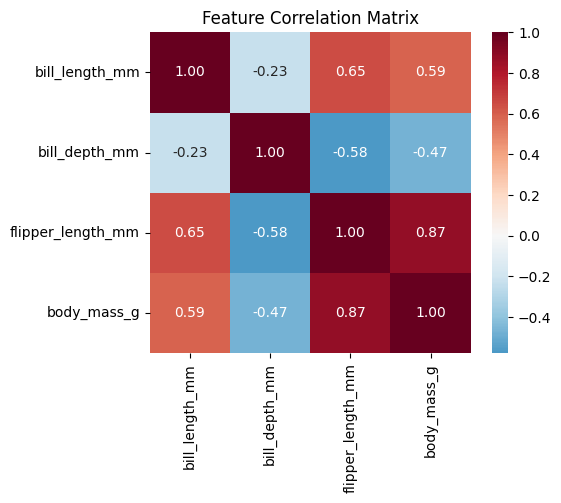

In [3]:
# Correlation matrix — which features are most related to body mass?
corr = df[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

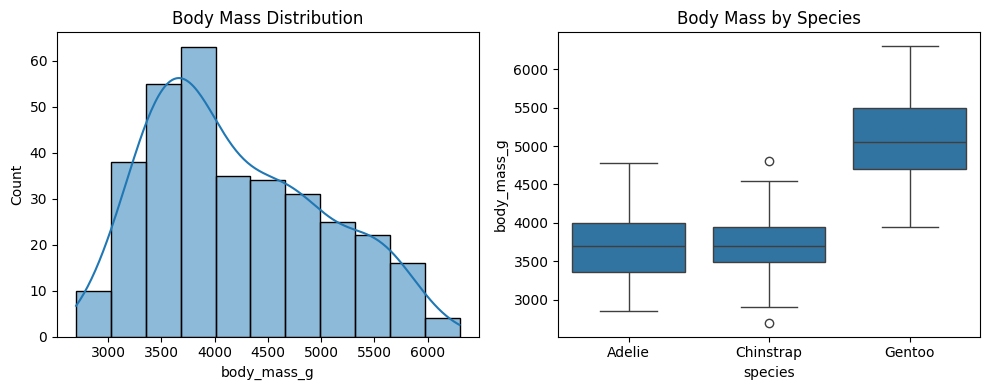

In [4]:
# Distribution of the target variable — body mass
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df["body_mass_g"], kde=True, ax=axes[0])
axes[0].set_title("Body Mass Distribution")

sns.boxplot(data=df, x="species", y="body_mass_g", ax=axes[1])
axes[1].set_title("Body Mass by Species")
plt.tight_layout()
plt.show()

### 🔍 Your Turn
**TODO:** Which feature has the strongest correlation with body_mass_g?
Does that make biological sense?

*Your answer:*

## 3. Feature Engineering
This is the content that separates a good ML practitioner from someone
who just calls `.fit()`. We create **new features** from domain knowledge.

In [5]:
# Bill ratio — captures beak shape independent of overall size
df["bill_ratio"] = df["bill_length_mm"] / df["bill_depth_mm"]

# Flipper-to-mass ratio — a kind of "wing loading"
df["flipper_mass_ratio"] = df["flipper_length_mm"] / df["body_mass_g"]

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=["species", "island", "sex"], drop_first=True)

print("New columns added:")
print([c for c in df_encoded.columns if c not in df.columns])
print(f"\nTotal features available: {df_encoded.shape[1]}")

New columns added:
['species_Chinstrap', 'species_Gentoo', 'island_Dream', 'island_Torgersen', 'sex_Male']

Total features available: 11


### 🔍 Your Turn: Create a Feature
**TODO:** Create at least one more engineered feature below. Ideas:
- `bill_area` = bill_length × bill_depth (proxy for beak surface area)
- `size_index` = flipper_length × body_mass (overall size metric)
- Something else you think might be informative!

In [6]:
# TODO: Add your engineered feature(s) here
# df["my_feature"] = ...

## 4. Multiple Linear Regression
**Goal:** Predict body_mass_g from the other measurements.

In [7]:
# Define features and target
# Start with the raw numeric features
feature_set_1 = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]
X1 = df_encoded[feature_set_1]
y = df_encoded["body_mass_g"]

# Split
X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.2, random_state=RANDOM_STATE
)

# Fit MLR
mlr1 = LinearRegression()
mlr1.fit(X1_train, y_train)
y_pred1 = mlr1.predict(X1_test)

# Evaluate
r2_1 = r2_score(y_test, y_pred1)
rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred1))
print(f"Model 1 (raw features only)")
print(f"  R² = {r2_1:.3f}")
print(f"  RMSE = {rmse_1:.0f} grams")

Model 1 (raw features only)
  R² = 0.798
  RMSE = 357 grams


In [8]:
# Feature coefficients — which features matter most?
coef_df = pd.DataFrame({
    "Feature": feature_set_1,
    "Coefficient": mlr1.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("\nFeature Coefficients:")
print(coef_df.to_string(index=False))


Feature Coefficients:
          Feature  Coefficient
flipper_length_mm    50.247255
    bill_depth_mm    10.058133
   bill_length_mm     3.857683


### Now with engineered features

In [9]:
feature_set_2 = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm",
                  "bill_ratio", "flipper_mass_ratio"]

# Remove flipper_mass_ratio since it uses the target — that's data leakage!
# Let's use features that don't include body_mass_g
feature_set_2 = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "bill_ratio"]

X2 = df_encoded[feature_set_2]
X2_train, X2_test, _, _ = train_test_split(
    X2, y, test_size=0.2, random_state=RANDOM_STATE
)

mlr2 = LinearRegression()
mlr2.fit(X2_train, y_train)
y_pred2 = mlr2.predict(X2_test)

r2_2 = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred2))

print(f"Model 1 (raw features):      R² = {r2_1:.3f}, RMSE = {rmse_1:.0f}g")
print(f"Model 2 (+ bill_ratio):      R² = {r2_2:.3f}, RMSE = {rmse_2:.0f}g")

Model 1 (raw features):      R² = 0.798, RMSE = 357g
Model 2 (+ bill_ratio):      R² = 0.816, RMSE = 340g


### 🔍 Your Turn: Data Leakage
**TODO:** We caught a data leakage bug above. `flipper_mass_ratio` uses
`body_mass_g` — the very thing we're trying to predict! Explain in your
own words why this would give misleadingly good results.

*Your answer:*

## 5. Residual Analysis
A good regression model should have residuals (errors) that are
randomly scattered around zero — no patterns.

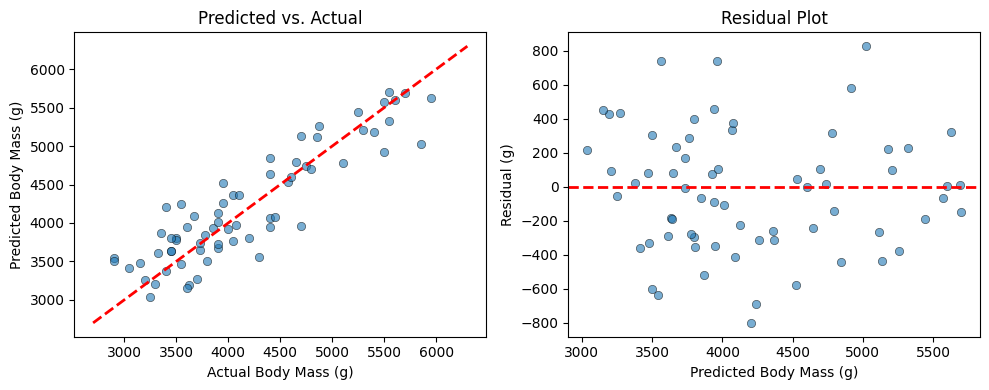

In [10]:
residuals = y_test - y_pred1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Predicted vs. Actual
axes[0].scatter(y_test, y_pred1, alpha=0.6, edgecolors="k", linewidth=0.5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
axes[0].set_xlabel("Actual Body Mass (g)")
axes[0].set_ylabel("Predicted Body Mass (g)")
axes[0].set_title("Predicted vs. Actual")

# Residuals vs. Predicted
axes[1].scatter(y_pred1, residuals, alpha=0.6, edgecolors="k", linewidth=0.5)
axes[1].axhline(y=0, color="r", linestyle="--", linewidth=2)
axes[1].set_xlabel("Predicted Body Mass (g)")
axes[1].set_ylabel("Residual (g)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

### 🔍 Your Turn
**TODO:** Do you see any patterns in the residual plot? What would a
perfectly random residual plot look like?

*Your answer:*

## 6. Does Species Matter?
**TODO:** Try adding the species dummy variables to your feature set.
Does the model improve? Fill in below:

In [11]:
# TODO: Build Model 3 with species included
species_cols = [c for c in df_encoded.columns if c.startswith("species_")]
feature_set_3 = feature_set_1 + species_cols

# X3 = df_encoded[feature_set_3]
# X3_train, X3_test, _, _ = train_test_split(X3, y, test_size=0.2, random_state=RANDOM_STATE)
# mlr3 = LinearRegression()
# mlr3.fit(X3_train, y_train)
# y_pred3 = mlr3.predict(X3_test)
# r2_3 = r2_score(y_test, y_pred3)
# rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred3))
# print(f"Model 3 (+ species): R² = {r2_3:.3f}, RMSE = {rmse_3:.0f}g")

---
## What to Submit
1. A PDF/doc with your answers to all **🔍 Your Turn** sections
2. Include the comparison table of your models (R² and RMSE for each)
3. Include at least one figure (predicted vs. actual or residual plot)
4. A link to your completed Colab notebook

## What's Next
**Data Adventure 1** is due this week — apply MLR to your chosen Data Path
(Rocks, Birds, Water, Space, or Hazards). Lab 3 introduces classification
algorithms: logistic regression and Naive Bayes.